# 1. Problem Statement
- Textile manufacturing machines can produce defective yarn when operating conditions such as temperature, speed, or torque become unstable. The goal of this project is to build a machine learning model that predicts whether a yarn will be defective or not.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Data loading through csv file
df = pd.read_csv('arvind_textile_machine_dataset_1000.csv')

In [3]:
df.head()

,Machine_ID,Temperature,Speed,Torque,Yarn_Type,Defect
0,M107,328,1430,58,Blend,0
1,M115,307,1607,53,Silk,0
2,M111,316,1439,63,Blend,1
3,M108,319,1181,64,Silk,0
4,M107,325,1390,64,Silk,1


### Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Machine_ID   1000 non-null   object
 1   Temperature  1000 non-null   int64 
 2   Speed        1000 non-null   int64 
 3   Torque       1000 non-null   int64 
 4   Yarn_Type    1000 non-null   object
 5   Defect       1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


In [5]:
df.isnull().sum()

Machine_ID     0
Temperature    0
Speed          0
Torque         0
Yarn_Type      0
Defect         0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['Yarn_Type'].unique()

array(['Blend', 'Silk', 'Polyester', 'Cotton'], dtype=object)

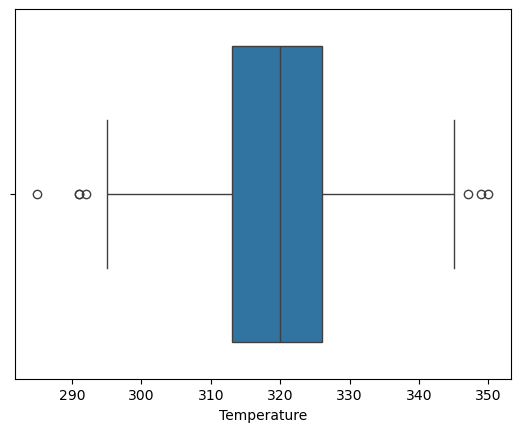

In [8]:
sns.boxplot(x=df['Temperature'])
plt.show()

** Interpretation**

- A few temperature outliers were detected. These may represent abnormal machine operating conditions rather than errors, so they were retained for further analysis.

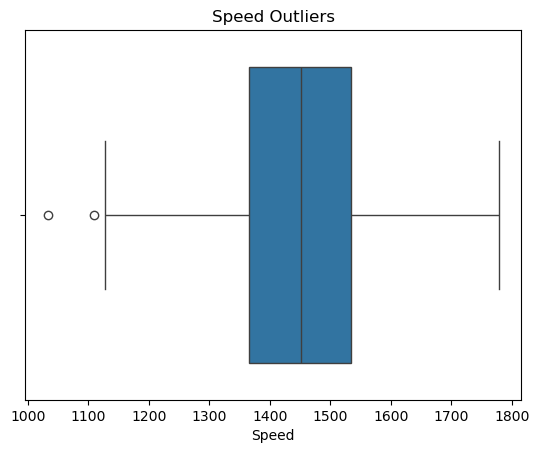

In [9]:
sns.boxplot(x=df['Speed'])
plt.title("Speed Outliers")
plt.show()

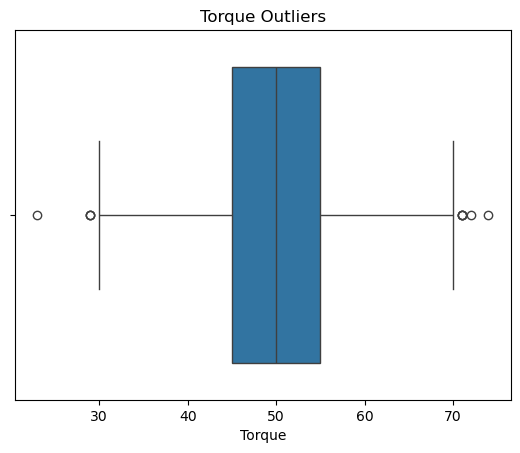

In [10]:
sns.boxplot(x=df['Torque'])
plt.title("Torque Outliers")
plt.show()

## visualization 

In [11]:
numeric_df = df.select_dtypes(include=['int64','float64'])

In [12]:
corr_matrix = numeric_df.corr()

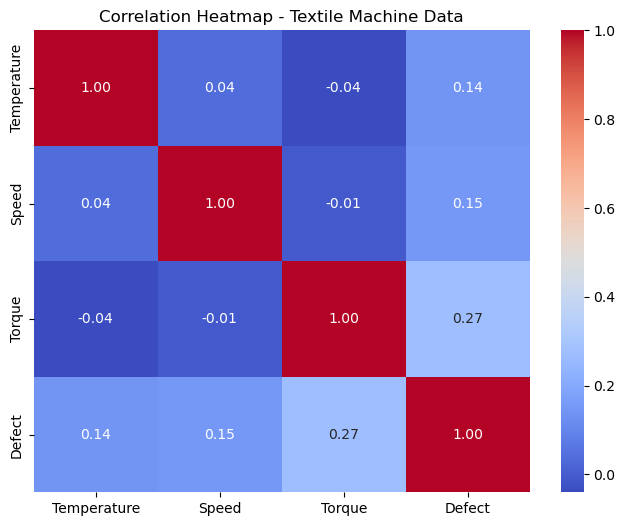

In [13]:
# heatmap to see the correlation
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap - Textile Machine Data")
plt.show()

**Interpretation**
 - The correlation heatmap indicates that torque has the highest correlation with machine defects (0.27), suggesting that mechanical load may slightly influence defect formation. Temperature and speed show very weak correlations with defects. Additionally, the low correlations between independent variables indicate minimal multicollinearity in the dataset.

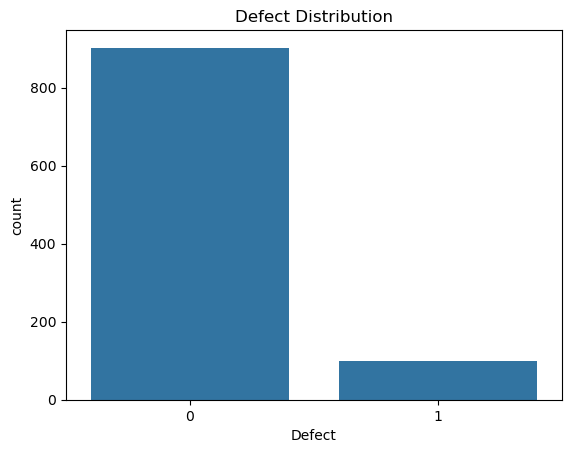

In [14]:
sns.countplot(x='Defect', data=df)

plt.title("Defect Distribution")
plt.show()

In [15]:
X = df.drop('Defect', axis=1)
y = df['Defect']

In [16]:
X = X.drop('Machine_ID', axis=1)

In [17]:
categorical_cols = ['Yarn_Type']
numerical_cols = ['Temperature', 'Speed', 'Torque']

### Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Model Building

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

In [20]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [22]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Yarn_Type'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [23]:
best_model = grid_search.best_estimator_

In [24]:
y_pred = best_model.predict(X_test)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       176
           1       0.60      0.88      0.71        24

    accuracy                           0.92       200
   macro avg       0.79      0.90      0.83       200
weighted avg       0.94      0.92      0.92       200



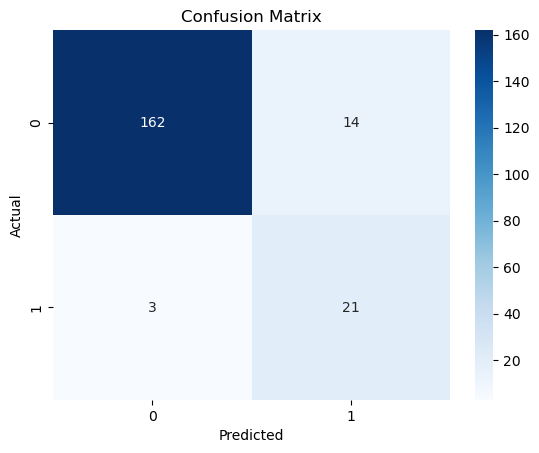

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

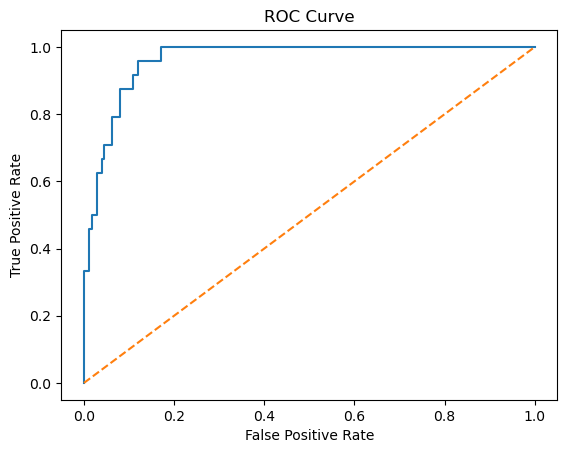

ROC AUC Score: 0.9623579545454546


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

In [29]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                    Feature  Importance
5         remainder__Torque    0.325952
4          remainder__Speed    0.246127
3    remainder__Temperature    0.202201
0     cat__Yarn_Type_Cotton    0.082136
1  cat__Yarn_Type_Polyester    0.080348
2       cat__Yarn_Type_Silk    0.063236


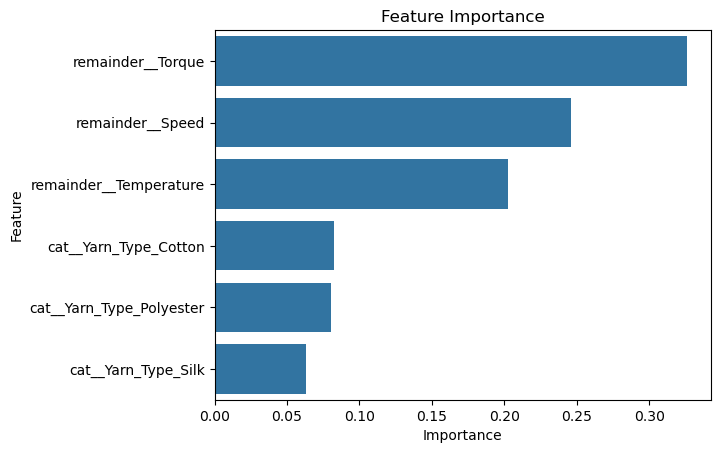

In [30]:
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()

In [32]:
# Save the model
import joblib

joblib.dump(best_model, "textile_defect_model.pkl")

['textile_defect_model.pkl']